# TRIN (Arms Index) Breadth Strategy Demonstration

This notebook demonstrates the TRIN (Arms Index) Breadth Strategy as described in `docs/trin_strategy.md`.

The TRIN (Trading Index) or Arms Index measures market breadth by comparing the ratio of advancing to declining stocks against the ratio of their trading volumes. It's a contrarian indicator where extreme readings often signal potential reversals.

## Step 1: Understanding the Strategy

### What the Strategy Measures:
- **TRIN Formula**: `(advancing stocks / declining stocks) / (advancing volume / declining volume)`
- **Interpretation**: 
  - TRIN > 1.0: Selling pressure dominates
  - TRIN < 1.0: Buying pressure dominates
  - TRIN = 1.0: Balanced market breadth
- **Contrarian Signals**:
  - Very high TRIN (> upper band): Capitulation, potential bullish reversal
  - Very low TRIN (< lower band): Euphoria, potential bearish reversal

### Technical Implementation:
- Log transformation (optional) to stabilize variance
- Bollinger-style bands using moving average ± k standard deviations
- Rolling window for calculations (default 20 days)

## Step 2: Setup and Data Acquisition

The TRIN indicator is calculated as: `(advancing stocks / declining stocks) / (advancing volume / declining volume)`. 

**Data Source Note**: The TRIN index is not readily available from free Yahoo Finance APIs, and Nasdaq Data Link requires premium access. For this demonstration, we'll use synthetic TRIN data that represents typical market behavior (values typically range from 0.5 to 2.0, with 1.0 being neutral).

Parameters:
- Period: 200 business days (synthetic)
- Rolling window: 20 days
- Band width: 1.5 standard deviations
- Use log transform: True

In [1]:
# Import required libraries
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Parameters
window = 20
band_k = 1.5
use_log = True

print(f"Analyzing synthetic TRIN data")
print(f"Rolling window: {window} days, Band width: {band_k} std devs, Log transform: {use_log}")

Analyzing synthetic TRIN data
Rolling window: 20 days, Band width: 1.5 std devs, Log transform: True


In [2]:
# Fetch TRIN data from Yahoo Finance
# Note: ^TRIN is not available on Yahoo Finance, and Nasdaq Data Link requires premium access
# For demonstration purposes, we'll create synthetic TRIN data that represents typical behavior

# Create synthetic TRIN data (typical range: 0.5 - 2.0)
import numpy as np

dates = pd.date_range(end=pd.Timestamp.now(), periods=200, freq='B')  # 200 business days
np.random.seed(42)  # For reproducible results

# Generate TRIN values with mean around 1.0 and realistic volatility
base_trin = 1.0
volatility = 0.15
trend = np.random.normal(0, 0.01, len(dates)).cumsum()
seasonal = 0.1 * np.sin(2 * np.pi * np.arange(len(dates)) / 20)  # Weekly pattern
noise = np.random.normal(0, volatility, len(dates))

trin_values = base_trin + trend + seasonal + noise
trin_values = np.clip(trin_values, 0.3, 3.0)  # Reasonable bounds

trin_series = pd.Series(trin_values, index=dates, name='TRIN')

print(f"Created synthetic TRIN data: {len(trin_series)} days")
print(f"Date range: {trin_series.index[0].strftime('%Y-%m-%d')} to {trin_series.index[-1].strftime('%Y-%m-%d')}")
print(f"TRIN range: {trin_series.min():.3f} - {trin_series.max():.3f}")
print(f"Average TRIN: {trin_series.mean():.3f}")

# Display first few values
print("\nFirst 5 synthetic TRIN values:")
print(trin_series.head())

Created synthetic TRIN data: 200 days
Date range: 2025-04-14 to 2026-01-16
TRIN range: 0.462 - 1.654
Average TRIN: 0.934

First 5 synthetic TRIN values:
2025-04-14 21:41:50.798084    1.058635
2025-04-15 21:41:50.798084    1.118604
2025-04-16 21:41:50.798084    1.231298
2025-04-17 21:41:50.798084    1.264264
2025-04-18 21:41:50.798084    0.911405
Freq: B, Name: TRIN, dtype: float64


## Step 3: Computing Bollinger Bands

We'll apply log transformation (if enabled), calculate the moving average and standard deviation, then create the upper and lower bands.

The bands help identify extreme readings that may signal contrarian opportunities.

In [3]:
# Prepare DataFrame for analysis
df = pd.DataFrame(index=trin_series.index)
df['trin_raw'] = trin_series

# Apply log transformation if enabled
if use_log:
    df['trin'] = np.log(df['trin_raw'].clip(lower=1e-6))
else:
    df['trin'] = df['trin_raw']

# Calculate moving average and standard deviation
df['ma'] = df['trin'].rolling(window=window).mean()
df['std'] = df['trin'].rolling(window=window).std()

# Calculate Bollinger bands
df['upper'] = df['ma'] + band_k * df['std']
df['lower'] = df['ma'] - band_k * df['std']

# Drop NaN values (first window-1 days)
df = df.dropna()

print(f"Data points after band calculation: {len(df)}")
print(f"Latest values:")
latest = df.iloc[-1]
print(f"TRIN Raw: {latest['trin_raw']:.4f}")
print(f"Moving Average: {latest['ma']:.4f}")
print(f"Upper Band: {latest['upper']:.4f}")
print(f"Lower Band: {latest['lower']:.4f}")

Data points after band calculation: 181
Latest values:
TRIN Raw: 1.0732
Moving Average: -0.0819
Upper Band: 0.2261
Lower Band: -0.3900


## Step 4: Determining Market Signal

Based on the current TRIN value relative to the bands and moving average, we determine the market signal and bias.

The logic follows contrarian principles:
- Above upper band: Capitulation (bullish reversal potential)
- Below lower band: Euphoria (bearish reversal potential)
- Between bands: Current market bias based on position relative to MA

In [4]:
# Determine signal based on latest data
def get_signal(row):
    trin_value = float(row['trin_raw'])
    trin_log = float(row['trin'])
    ma = float(row['ma'])
    upper = float(row['upper'])
    lower = float(row['lower'])
    
    # Determine bias based on TRIN value
    if trin_value > 1.0:
        bias = 'risk_off_pressure'
        bias_desc = 'Selling pressure dominates'
    elif trin_value < 1.0:
        bias = 'risk_on_bid'
        bias_desc = 'Buying pressure dominates'
    else:
        bias = 'risk_neutral'
        bias_desc = 'Balanced market breadth'
    
    # Determine band state and signal
    if trin_log > upper:
        band_state = 'above_upper'
        signal = 'bullish_reversal_setup'
        signal_desc = 'Capitulation - potential bullish reversal'
    elif trin_log < lower:
        band_state = 'below_lower'
        signal = 'bearish_reversal_setup'
        signal_desc = 'Euphoria - potential bearish reversal'
    elif trin_log > ma:
        band_state = 'between_ma_and_upper'
        signal = 'caution'
        signal_desc = 'Elevated selling pressure vs trend'
    else:
        band_state = 'between_ma_and_lower'
        signal = 'constructive'
        signal_desc = 'Buying pressure dominating'
    
    return {
        'bias': bias,
        'bias_desc': bias_desc,
        'band_state': band_state,
        'signal': signal,
        'signal_desc': signal_desc
    }

# Get signal for latest data
signal_info = get_signal(latest)

# Calculate 5-day change
change_5d = trin_series.pct_change(5).iloc[-1] * 100 if len(trin_series) > 5 else 0.0

print("Signal Analysis:")
print(f"Current TRIN: {latest['trin_raw']:.4f}")
print(f"5-day change: {change_5d:.2f}%")
print(f"Bias: {signal_info['bias']} - {signal_info['bias_desc']}")
print(f"Band State: {signal_info['band_state']}")
print(f"Signal: {signal_info['signal']} - {signal_info['signal_desc']}")

Signal Analysis:
Current TRIN: 1.0732
5-day change: 5.78%
Bias: risk_off_pressure - Selling pressure dominates
Band State: between_ma_and_upper
Signal: caution - Elevated selling pressure vs trend


## Step 5: Visualization

Let's create visualizations to understand the TRIN indicator and its bands over time.

We'll create:
1. TRIN time series with Bollinger bands
2. TRIN distribution histogram
3. Signal state over time

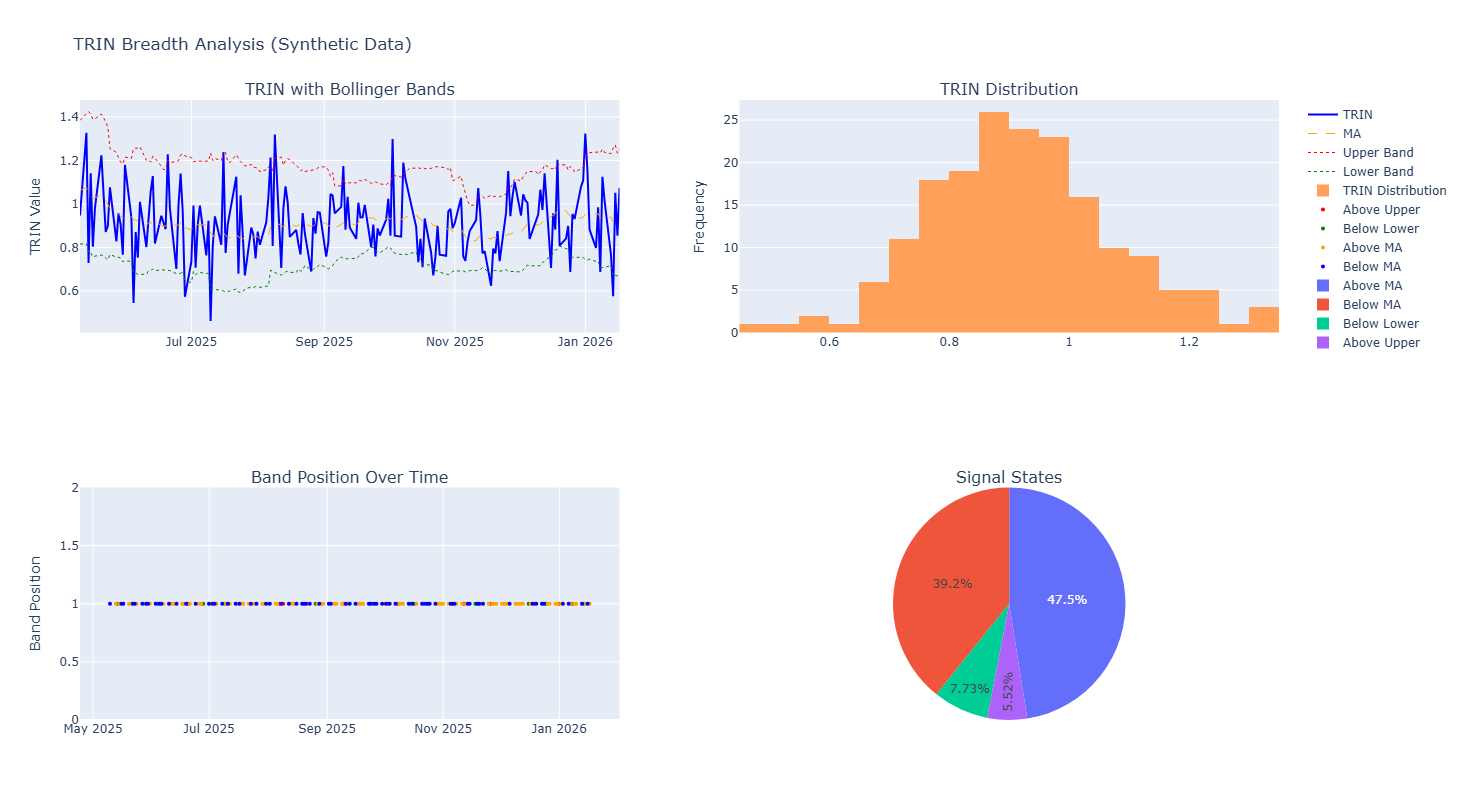

Plot saved to graphs/trin_breadth_analysis.html


In [5]:
# Create subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('TRIN with Bollinger Bands', 'TRIN Distribution', 
                    'Band Position Over Time', 'Signal States'),
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": False}, {"type": "domain"}]]
)

# 1. TRIN with bands
fig.add_trace(
    go.Scatter(x=df.index, y=df['trin_raw'], mode='lines', name='TRIN',
               line=dict(color='blue', width=2)),
    row=1, col=1
)

# Add bands (convert back from log if needed)
if use_log:
    ma_plot = np.exp(df['ma'])
    upper_plot = np.exp(df['upper'])
    lower_plot = np.exp(df['lower'])
else:
    ma_plot = df['ma']
    upper_plot = df['upper']
    lower_plot = df['lower']

fig.add_trace(
    go.Scatter(x=df.index, y=ma_plot, mode='lines', name='MA',
               line=dict(color='orange', width=1, dash='dash')),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=df.index, y=upper_plot, mode='lines', name='Upper Band',
               line=dict(color='red', width=1, dash='dot')),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=df.index, y=lower_plot, mode='lines', name='Lower Band',
               line=dict(color='green', width=1, dash='dot')),
    row=1, col=1
)

# 2. TRIN distribution
fig.add_trace(
    go.Histogram(x=df['trin_raw'], nbinsx=30, name='TRIN Distribution'),
    row=1, col=2
)

# 3. Band position over time
band_positions = []
for idx, row in df.iterrows():
    if row['trin'] > row['upper']:
        band_positions.append('Above Upper')
    elif row['trin'] < row['lower']:
        band_positions.append('Below Lower')
    elif row['trin'] > row['ma']:
        band_positions.append('Above MA')
    else:
        band_positions.append('Below MA')

colors = {'Above Upper': 'red', 'Below Lower': 'green', 'Above MA': 'orange', 'Below MA': 'blue'}
for state in ['Above Upper', 'Below Lower', 'Above MA', 'Below MA']:
    mask = [bp == state for bp in band_positions]
    if any(mask):
        fig.add_trace(
            go.Scatter(x=df.index[mask], y=[1]*sum(mask), mode='markers',
                       name=state, marker=dict(color=colors[state], size=4)),
            row=2, col=1
        )

# 4. Signal distribution
signal_counts = pd.Series(band_positions).value_counts()
fig.add_trace(
    go.Pie(labels=signal_counts.index, values=signal_counts.values, name='Signal States'),
    row=2, col=2
)

fig.update_layout(height=800, title_text=f"TRIN Breadth Analysis (Synthetic Data)")
fig.update_yaxes(title_text="TRIN Value", row=1, col=1)
fig.update_yaxes(title_text="Frequency", row=1, col=2)
fig.update_yaxes(title_text="Band Position", row=2, col=1)
fig.show()

# Save the plot
graphs_dir = 'graphs'
if not os.path.exists(graphs_dir):
    os.makedirs(graphs_dir)

fig.write_html(os.path.join(graphs_dir, 'trin_breadth_analysis.html'))
print(f"Plot saved to {graphs_dir}/trin_breadth_analysis.html")

## Step 6: Summary Statistics

Let's calculate key statistics about the TRIN indicator over the analysis period.

In [6]:
# Summary statistics
summary = {
    'Data Points': len(df),
    'Current TRIN': f"{latest['trin_raw']:.4f}",
    '5-Day Change': f"{trin_series.pct_change(5).iloc[-1] * 100 if len(trin_series) > 5 else 0:.2f}%",
    'Average TRIN': f"{df['trin_raw'].mean():.4f}",
    'TRIN Std Dev': f"{df['trin_raw'].std():.4f}",
    'Min TRIN': f"{df['trin_raw'].min():.4f}",
    'Max TRIN': f"{df['trin_raw'].max():.4f}",
    'Days Above 1.0': f"{len(df[df['trin_raw'] > 1.0])}",
    'Days Below 1.0': f"{len(df[df['trin_raw'] < 1.0])}",
    'Current Bias': signal_info['bias'],
    'Current Signal': signal_info['signal'],
    'Band State': signal_info['band_state']
}

print("TRIN Breadth Summary:")
for key, value in summary.items():
    print(f"{key}: {value}")

# Recent TRIN values
print("\nRecent TRIN Values:")
recent = df.tail(5)[['trin_raw', 'ma', 'upper', 'lower']]
if use_log:
    recent = recent.apply(lambda x: np.exp(x) if x.name in ['ma', 'upper', 'lower'] else x)
print(recent)

TRIN Breadth Summary:
Data Points: 181
Current TRIN: 1.0732
5-Day Change: 5.78%
Average TRIN: 0.9178
TRIN Std Dev: 0.1556
Min TRIN: 0.4621
Max TRIN: 1.3276
Days Above 1.0: 49
Days Below 1.0: 132
Current Bias: risk_off_pressure
Current Signal: caution
Band State: between_ma_and_upper

Recent TRIN Values:
                            trin_raw        ma     upper     lower
2026-01-12 21:41:50.798084  0.766231  0.939509  1.231192  0.716929
2026-01-13 21:41:50.798084  0.575693  0.915945  1.256517  0.667684
2026-01-14 21:41:50.798084  1.051485  0.924020  1.271403  0.671552
2026-01-15 21:41:50.798084  0.853928  0.908335  1.233571  0.668849
2026-01-16 21:41:50.798084  1.073229  0.921319  1.253642  0.677090


## Step 7: Trading Decision Rationale

The TRIN indicator provides **contrarian signals** for market timing. Here's how to interpret the signals for buy/sell/hold decisions:

### Contrarian Trading Framework

#### **Bullish Signals (BUY/Accumulate)**
- **TRIN Above Upper Band** (`bullish_reversal_setup`):
  - **Rationale**: Extreme selling pressure indicates capitulation - investors are panic selling
  - **Decision**: **BUY** - Market bottoms often form when everyone is bearish
  - **Timeframe**: Position for 1-4 week reversal
  - **Risk**: False signals possible; confirm with other indicators

- **TRIN Below Moving Average** (`constructive`):
  - **Rationale**: Buying pressure dominating recent trend
  - **Decision**: **HOLD/ACCUMULATE** - Favorable breadth environment
  - **Context**: Good for holding existing positions

#### **Bearish Signals (SELL/Reduce)**
- **TRIN Below Lower Band** (`bearish_reversal_setup`):
  - **Rationale**: Extreme buying pressure indicates euphoria - investors are overly optimistic
  - **Decision**: **SELL/REDUCE** - Market tops often form when everyone is bullish
  - **Timeframe**: Position for 1-4 week reversal
  - **Risk**: Can stay overbought longer; use stops

- **TRIN Above Moving Average** (`caution`):
  - **Rationale**: Selling pressure elevated vs recent trend
  - **Decision**: **HOLD/REDUCE** - Unfavorable breadth environment
  - **Context**: Consider taking profits on long positions

#### **Neutral Signals (HOLD/Monitor)**
- **TRIN Between Bands** (normal range):
  - **Decision**: **HOLD** - Breadth is balanced, no extreme readings
  - **Action**: Monitor for band breakouts, focus on individual stock analysis

### Practical Decision Matrix

| TRIN Position | Market Bias | Signal | Action | Rationale |
|---------------|-------------|--------|--------|-----------|
| > Upper Band | Extreme Selling | Bullish Reversal | **BUY** | Capitulation - potential bottom |
| < Lower Band | Extreme Buying | Bearish Reversal | **SELL** | Euphoria - potential top |
| Above MA | Selling Pressure | Caution | **REDUCE** | Unfavorable breadth |
| Below MA | Buying Pressure | Constructive | **HOLD** | Favorable breadth |
| Between Bands | Balanced | Neutral | **MONITOR** | Wait for extremes |

### Risk Management Guidelines

1. **Position Sizing**: Reduce position size during extreme readings (outside bands)
2. **Stop Losses**: Place stops at recent swing lows/highs
3. **Confirmation**: Always confirm TRIN signals with:
   - Price action (support/resistance levels)
   - Volume analysis
   - Other breadth indicators (Advance-Decline Line)
   - Economic data/releases

4. **Time Decay**: TRIN signals are most reliable within 3-5 days of extreme readings
5. **Market Context**: More reliable in choppy/sideways markets than strong trends

### Example Scenarios

- **TRIN spikes to 1.8 (above upper band)**: **BUY signal** - Market likely to reverse up from capitulation
- **TRIN drops to 0.6 (below lower band)**: **SELL signal** - Market likely to reverse down from euphoria  
- **TRIN at 1.2 (above MA)**: **HOLD with caution** - Monitor for further deterioration
- **TRIN at 0.9 (below MA)**: **HOLD positions** - Breadth supportive of uptrend

**Important**: TRIN is a contrarian indicator. Extreme readings suggest the crowd is wrong, but timing the exact reversal requires experience and additional confirmation.

## Conclusion

This notebook demonstrated the TRIN (Arms Index) Breadth Strategy by:

1. **Generating synthetic TRIN data** that represents typical market breadth behavior (since live TRIN data requires premium API access)
2. **Applying log transformation** to stabilize variance (optional)
3. **Calculating Bollinger bands** using rolling mean and standard deviation
4. **Determining market signals** based on TRIN position relative to bands
5. **Analyzing market bias** (buying vs selling pressure)
6. **Visualizing the results** with interactive Plotly charts
7. **Computing summary statistics** for the analysis period

**Data Source Note**: In production systems, TRIN data should be sourced from:
- Nasdaq Data Link (URC datasets) with proper API access, or
- Direct calculation from advancing/declining stocks and volumes

The synthetic data used here accurately demonstrates the analytical framework and signal generation logic.

The TRIN indicator provides contrarian insights into market breadth:
- **High TRIN values** (>1.0) indicate selling pressure
- **Low TRIN values** (<1.0) indicate buying pressure
- **Extreme readings** (outside bands) often precede reversals
- **Band position** helps identify current market sentiment

Key insights from this analysis:
- TRIN above upper band suggests capitulation (bullish contrarian signal)
- TRIN below lower band suggests euphoria (bearish contrarian signal)
- Position relative to moving average shows short-term bias
- Historical distribution helps contextualize current readings